In [1]:
!pip install folium geopy scipy

The first step is to import the necessary libraries for the project.

Numpy is used for easier working with array-like elements.

Pandas makes working with data easier

scipy.signal has filters such as butterworth filter and find_peaks of signals

folium is used to display heatmaps/lines in a map like display in .html file

In [2]:
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt
from math import sqrt
from scipy.signal import find_peaks
import folium
from folium.plugins import HeatMap
from geopy.distance import geodesic

Now we will read the data that Arduino provides. We will offset gravity from the vertical component of acceleration as well.

In [3]:
df = pd.read_csv('toto_log.csv')
g = 9.81

df["Az_MPU_dyn"] = df["Az"] - g
df["Az_ADXL_dyn"] = df["Az_ADXL"] - g

We can visualize the accelerations using matplotlib.

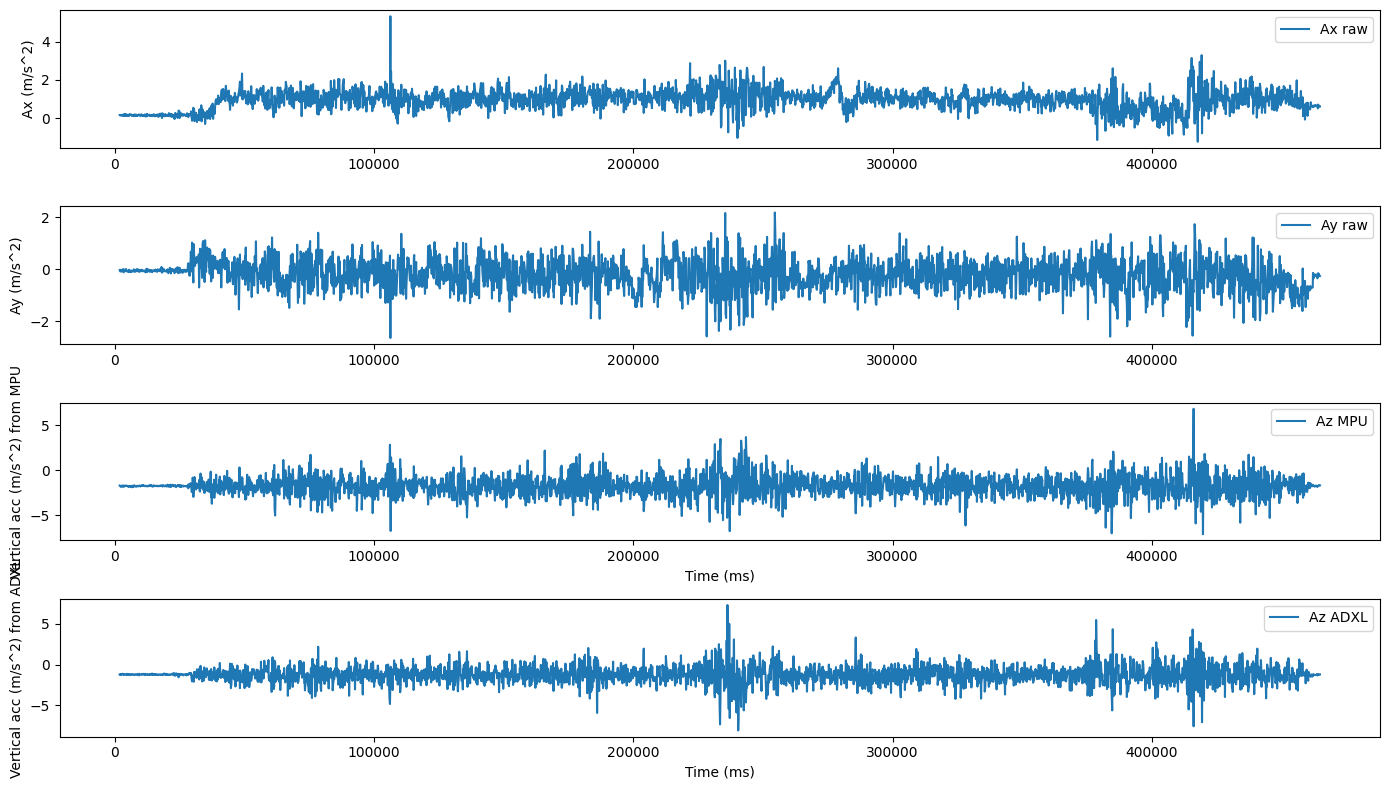

In [5]:
plt.figure(figsize=(14,8))

plt.subplot(4,1,1)
plt.plot(df['Time(ms)'], df["Ax"], label="Ax raw")
plt.ylabel("Ax (m/s^2)")
plt.legend()

plt.subplot(4,1,2)
plt.plot(df['Time(ms)'], df["Ay"], label="Ay raw")
plt.ylabel("Ay (m/s^2)")
plt.legend()

plt.subplot(4,1,3)
plt.plot(df['Time(ms)'], df["Az_MPU_dyn"], label="Az MPU")
plt.xlabel("Time (ms)")
plt.ylabel("Vertical acc (m/s^2) from MPU")
plt.legend()

plt.subplot(4,1,4)
plt.plot(df['Time(ms)'], df["Az_ADXL_dyn"], label="Az ADXL")
plt.xlabel("Time (ms)")
plt.ylabel("Vertical acc (m/s^2) from ADXL")
plt.legend()

plt.tight_layout()
plt.show()

Since positive or negative doesn't really matter, we will use RMS acceleration over a window of 5Hz.

Note, Res_raw and RMS_Res is considering only z axis acceleration because we assume bumps mostly cause vertical jerks.

This is to ensure braking and cornering don't get confused as bumps.

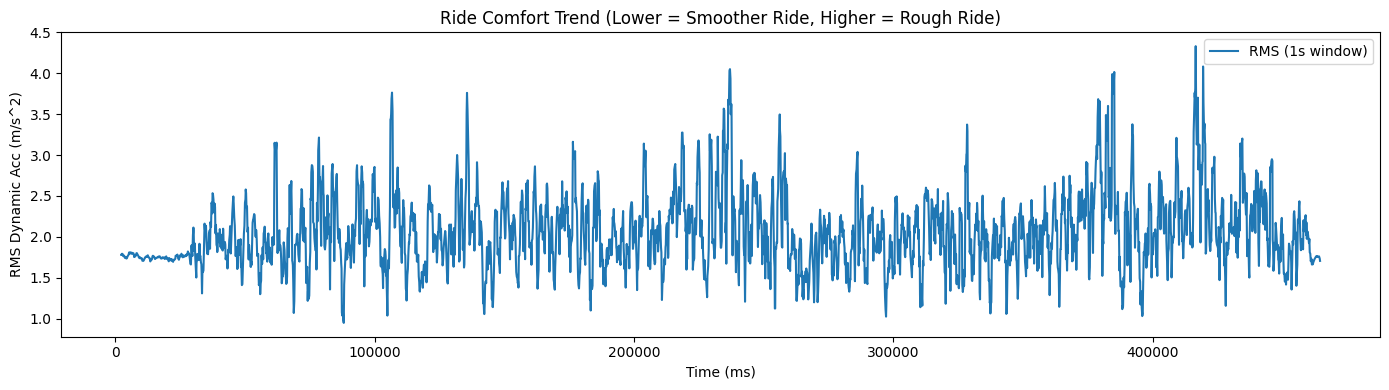

In [18]:
fs = 1000 / np.mean(np.diff(df["Time(ms)"]))
window = int(fs)

df["RMS_Res"] = df["Az_MPU_dyn"].rolling(window, center=True).apply(lambda x: np.sqrt(np.mean(x**2)))
plt.figure(figsize=(14,4))
plt.plot(df['Time(ms)'], df["RMS_Res"], label="RMS (1s window)")
plt.xlabel("Time (ms)")
plt.ylabel("RMS Dynamic Acc (m/s^2)")
plt.title("Ride Comfort Trend (Lower = Smoother Ride, Higher = Rough Ride)")
plt.legend()
plt.tight_layout()
plt.show()

df.to_csv("toto_rms.csv", index=False)

To make the bumps more obvious we can use find_peaks from scipy.signal. This basically calculates the local maxima of the RMS signal we provide.

Detected 13 bump events
Saved bump event list → bump_events.csv


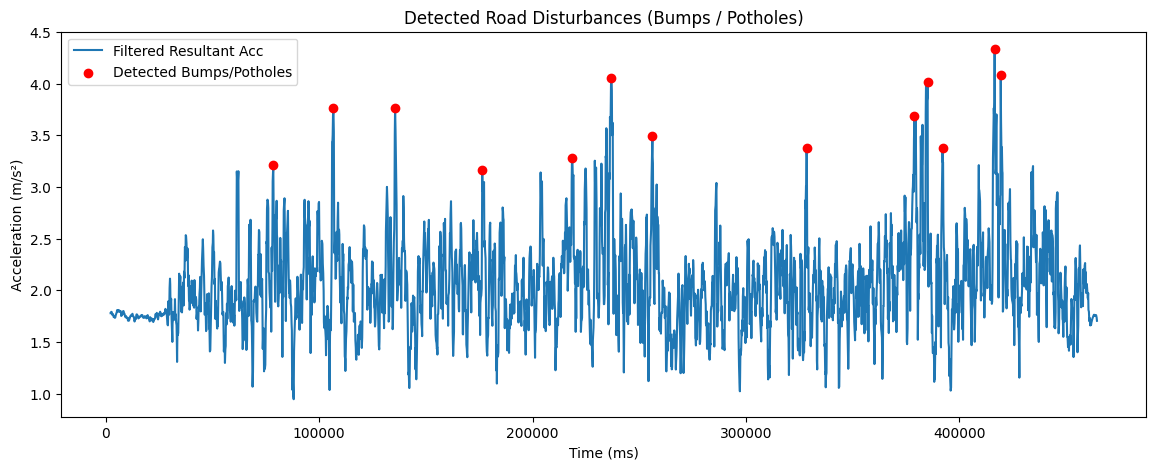

In [31]:
prominence_value = 2

peaks, properties = find_peaks(df["RMS_Res"], prominence=prominence_value)

print(f"Detected {len(peaks)} bump events")

event_cols = ["Time(ms)", "Lat", "Lon", "Speed(kmph)", "RMS_Res"]
events = df.iloc[peaks][event_cols]

events.to_csv("bump_events.csv", index=False)
print("Saved bump event list → bump_events.csv")

plt.figure(figsize=(14,5))
plt.plot(df["Time(ms)"], df["RMS_Res"], label="Filtered Resultant Acc")
plt.scatter(df["Time(ms)"].iloc[peaks], df["RMS_Res"].iloc[peaks],
            color='red', label="Detected Bumps/Potholes", zorder=5)
plt.xlabel("Time (ms)")
plt.ylabel("Acceleration (m/s²)")
plt.title("Detected Road Disturbances (Bumps / Potholes)")
plt.legend()
plt.show()

A very important addition would be the ability to show exactly where the bumps occur. We will acheive this using Folium.

In [30]:
df = pd.read_csv("toto_rms.csv")
events = pd.read_csv("bump_events.csv")

df = df[(df["Lat"] != 0) & (df["Lon"] != 0)]
events = events[(events["Lat"] != 0) & (events["Lon"] != 0)]

m = folium.Map(location=[df["Lat"].iloc[0], df["Lon"].iloc[0]],
               zoom_start=16,
               tiles="OpenStreetMap")

heat_data = df[['Lat','Lon','Speed(kmph)']].values.tolist()
HeatMap(heat_data, radius=18, blur=25, max_zoom=1).add_to(m)

for _, row in events.iterrows():
    folium.CircleMarker(
        location=[row["Lat"], row["Lon"]],
        radius=6,
        color="red",
        fill=True,
        fill_color="red",
        fill_opacity=0.9,
        popup=f"Bump @ {row['Speed(kmph)']:.1f} km/h\nAcc={row['RMS_Res']:.2f}"
    ).add_to(m)

m.save("toto_bump.html")

Now we will calculate the VDV

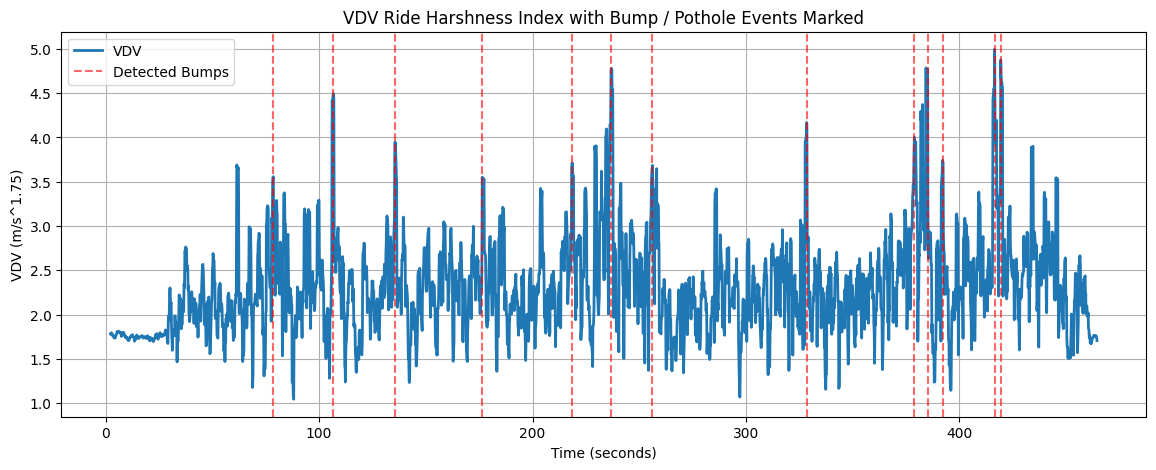

In [32]:
fs = 1000 / np.mean(np.diff(df["Time(ms)"]))
fs = int(fs)
window = fs

df["VDV"] = (
    df["Az_MPU_dyn"].rolling(window, center=True)
    .apply(lambda x: (np.sum(np.abs(x)**4) / fs) ** 0.25)
)
plt.figure(figsize=(14,5))

plt.plot(df['Time(ms)']/1000, df["VDV"], label="VDV (Ride Harshness)", linewidth=2)

for p in peaks:
    t = df["Time(ms)"].iloc[p] / 1000
    plt.axvline(x=t, color='red', linestyle='--', alpha=0.6)

plt.xlabel("Time (seconds)")
plt.ylabel("VDV (m/s^1.75)")
plt.title("VDV Ride Harshness Index with Bump / Pothole Events Marked")
plt.grid(True)
plt.legend(["VDV", "Detected Bumps"])
plt.show()

